In [80]:
import pandas as pd
import datetime as dt
import numpy as np


def strip_columns(df_raw) -> pd.DataFrame:
  df = df_raw.copy()
  stripped_columns = [col.strip() for col in df.columns]
  df.columns = stripped_columns
  return df

def mark_end_of_file(df_raw) -> pd.DataFrame:
  df = df_raw.copy()
  mask_end_of_data = df["Date"] == "END OF DATA"
  idx_eod_of_data = df[mask_end_of_data].index[0]
  df = df.iloc[:idx_eod_of_data-1, :]
  return df

# Month-Year
def process_date_month_year(val):
  if val is not None and isinstance(val, str) and "-" in val:
    if not pd.isna(pd.to_numeric(val, errors='coerce')):
      return None

    # if two occurrences of "-", return None
    if val.count("-") > 1:
      return None

    try:
      month_code, year_short = val.split("-")
      if len(month_code) == 3 and len(year_short) == 2:
        if int(year_short) <= 26:
          year = 2000 + int(year_short)
        else:
          year = 1900 + int(year_short)

        # convert 3-letter monthcode into month
        month = dt.datetime.strptime(month_code, "%b").month
        return dt.datetime(year, month, 1)
    except Exception as e:
      print(f"process_date_month_year: original value {val}", e)
  return None

def process_date_six_digit(val):
  if val is not None and isinstance(val, str) and len(val) == 6 and "-" not in val and "/" not in val and "°" not in val:
    try:
      year = int(val[:4])
      month = int(val[4:])
      return dt.datetime(year, month, 1)
    except Exception as e:
      print(f"process_date_six_digit: original value {val}", e)
  return None

def try_parse_datetime(val, max_year: int = 2026) -> np.datetime64:
  dt_obj = pd.to_datetime(val, errors="coerce")
  if pd.isna(dt_obj):
    return None
  if dt_obj.year > max_year and dt_obj.year < 2100:
    return dt_obj.replace(year=dt_obj.year - 100).to_datetime64()
  return dt_obj.to_datetime64()

In [81]:
df_input = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/global_temp_dirty_v2.csv")
df_input = strip_columns(df_input)
df_input = mark_end_of_file(df_input)

In [82]:
# Date Cleanup, Date Column
count_swap = 0
count_date_six_digit = 0
count_date_month_year = 0
count_date_other = 0

df_raw = df_input.copy()

for idx, row in df_raw.iterrows():
  date_val = row["Date"]
  temperature_val = row["Temperature_Anomaly"]

  date_val_processed = try_parse_datetime(date_val)
  if not pd.isna(date_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = date_val_processed
    count_date_other += 1

  date_val_processed = process_date_month_year(date_val)
  if not pd.isna(date_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = date_val_processed
    count_date_month_year += 1

  date_val_processed = process_date_six_digit(date_val)
  if not pd.isna(date_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = date_val_processed
    count_date_six_digit += 1


  temperature_val_processed = try_parse_datetime(temperature_val)
  if not pd.isna(temperature_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = temperature_val_processed
    df_raw.loc[idx, "Temperature_Anomaly"] = date_val
    count_date_other += 1
    count_swap += 1

  temperature_val_processed = process_date_month_year(temperature_val)
  if not pd.isna(temperature_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = temperature_val_processed
    df_raw.loc[idx, "Temperature_Anomaly"] = date_val
    count_date_month_year += 1
    count_swap += 1

  temperature_val_processed = process_date_six_digit(temperature_val)
  if not pd.isna(temperature_val_processed):
    df_raw.loc[idx, "Date Cleaned"] = temperature_val_processed
    df_raw.loc[idx, "Temperature_Anomaly"] = date_val
    count_date_six_digit += 1
    count_swap += 1



In [109]:
# Value Cleanup
SENSOR_MALFUNCTION_CODES = [500, -500, 999, -999, "500", "-500", "999", "-999"]

def check_malfunction_code(val):
  if val in SENSOR_MALFUNCTION_CODES:
    return None
  elif isinstance(val, str) and val.strip() in SENSOR_MALFUNCTION_CODES:
    return None
  return val


# Inconsistent numeric formatting, including comma decimal separators ("-0,199") and a unit suffix (0.253°C).
def check_numeric_formatting(val):

  if isinstance(val, str) and "," in val:
    return float(val.replace(",", "."))
  if isinstance(val, str) and "°" in val:
    return float(val.replace("°C", "").replace("°F", ""))
  return val

# Missing-value tokens: blank, ., --, NaN, null, NA, N/A, #N/A, n/a, and missing
MISSINV_VALUE_TOKEN_LIST = ["", ".", "--", "NaN", "null", "NA", "N/A", "#N/A", "n/a", "missing"]
def check_missing_value_tokens(val):
  if isinstance(val, str):
    val = val.strip()
  if val in MISSINV_VALUE_TOKEN_LIST:
    return None
  return val

In [83]:
df_raw[df_raw["Date Cleaned"].isna()]

,Date,Temperature_Anomaly,Source/Notes,Date Cleaned


In [124]:
#count_malfunction_code = 0
count_numeric_formatting = 0
count_missing_str = 0

df_clean = df_raw.copy()
df_clean["Temperature_Anomaly Cleaned"] = "<PLACEHOLDER>"


for idx, row in df_clean.iterrows():
  temperature_val = row["Temperature_Anomaly"]

  temperature_val_processed = check_numeric_formatting(temperature_val)
  if not pd.isna(temperature_val_processed):
    df_clean.loc[idx, "Temperature_Anomaly Cleaned"] = temperature_val_processed
    count_numeric_formatting += 1

  temperature_val_processed = check_missing_value_tokens(temperature_val)
  if pd.isna(temperature_val_processed):
    df_clean.loc[idx, "Temperature_Anomaly Cleaned"] = None
    count_missing_str += 1


  #temperature_val_processed = check_malfunction_code(temperature_val)
  #if pd.isna(temperature_val_processed):
  #  df_clean.loc[idx, "Temperature_Anomaly Cleaned"] = None
  #  count_malfunction_code += 1

df_clean["Temperature_Anomaly Cleaned"] = df_clean["Temperature_Anomaly Cleaned"].astype(float)

In [125]:
df_clean[df_clean["Temperature_Anomaly Cleaned"] == "<PLACEHOLDER>"]

,Date,Temperature_Anomaly,Source/Notes,Date Cleaned,Temperature_Anomaly Cleaned


In [126]:
# Sort

In [127]:
df_clean = df_clean.sort_values("Date Cleaned")
total_clean_count = df_clean.shape[0]
df_clean = df_clean.drop_duplicates("Date Cleaned")
count_duplicate_date = total_clean_count - df_clean.shape[0]

In [128]:
df_clean = df_clean[["Date Cleaned", "Temperature_Anomaly Cleaned"]]
df_clean.columns = ["Date", "Temperature_Anomaly"]
df_clean.set_index("Date", inplace=True)

<Axes: xlabel='Date'>

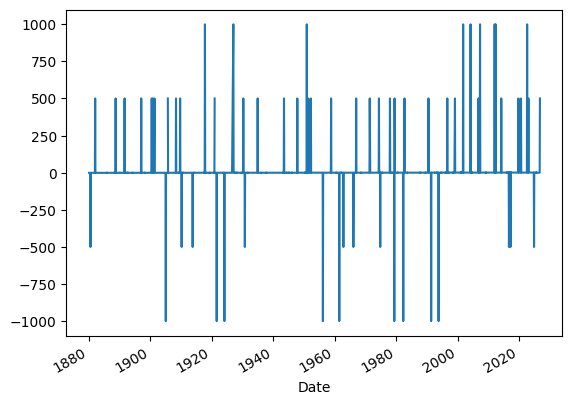

In [129]:
df_clean["Temperature_Anomaly"].plot()

In [150]:
# IQR Method
def outlier_process_iqr(df_raw):
  df = df_raw.copy()

  Q1 = df.quantile(0.25)
  Q3 = df.quantile(0.75)
  IQR = Q3 - Q1
  lo = Q1 - 1.5 * IQR
  hi = Q3 + 1.5 * IQR
  greater_than_q1 = df > lo
  smaller_than_q3 = df < hi

  count_removed = df[~greater_than_q1].dropna().shape[0] + df[~smaller_than_q3].dropna().shape[0]
  df[~greater_than_q1] = None
  df[~smaller_than_q3] = None
  return df, Q1, Q3, lo, hi, IQR, count_removed

In [154]:
df_processed, q1, q3, fence_lo, fence_hi, iqr_range, count_iqr_removed = outlier_process_iqr(df_clean)

In [155]:
count_iqr_removed

63

<Axes: xlabel='Date'>

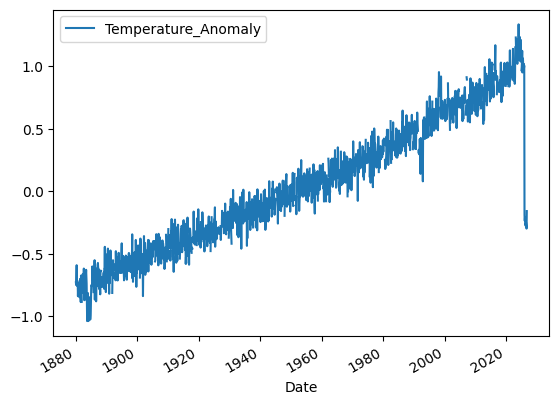

In [156]:
df_processed.plot()

In [159]:
# Missing Value Imputation
df_processed_full = df_processed.reindex(pd.date_range("1880-01-01", "2025-12-01", freq="MS"))

count_imputed = df_processed_full.isna().sum().iloc[0]
df_processed_full = df_processed_full.interpolate("linear", limit_direction="both")

In [160]:
count_imputed

np.int64(198)

In [177]:
mu_20 = df_processed_full["1901":"2000"].mean().iloc[0]
df_processed_full["d"] = df_processed_full["Temperature_Anomaly"] - mu_20


In [178]:
mu = df_processed_full.mean().iloc[0]
sigma = df_processed_full.std().iloc[0]
df_processed_full["z"] = (df_processed_full["Temperature_Anomaly"] - mu) / sigma

In [179]:
df_processed_full

,Temperature_Anomaly,d,z
1880-01-01,-0.7300,-0.729467,-1.491634
1880-02-01,-0.7520,-0.751467,-1.533925
1880-03-01,-0.6700,-0.669467,-1.376294
1880-04-01,-0.5930,-0.592467,-1.228275
1880-05-01,-0.7390,-0.738467,-1.508934
...,...,...,...
2025-08-01,0.9990,0.999533,1.832067
2025-09-01,1.0075,1.008033,1.848407
2025-10-01,1.0160,1.016533,1.864747
2025-11-01,0.9850,0.985533,1.805155


In [180]:
# Annual summary
from numpy import average
# yearly mean, yearly z-score
res_list = []
for year in range(1880, 2026):
  df_sub = df_processed_full[df_processed_full.index.year == year]
  mean_year = df_sub.mean().iloc[0]
  std_year = df_sub.std().iloc[0]
  z_score_year = ((df_sub - mean_year) / std_year).mean().iloc[0]
  res = {
      "year": year,
      "mean": mean_year,
      "std": std_year,
      "z_score": z_score_year
  }
  res_list.append(res)

df_res = pd.DataFrame(res_list)

In [181]:
df_res

,year,mean,std,z_score
0,1880,-0.747500,0.069850,9.251859e-16
1,1881,-0.792125,0.066920,-4.070818e-16
2,1882,-0.757875,0.074096,-4.625929e-16
3,1883,-0.820500,0.135178,9.084169e-16
4,1884,-0.917542,0.068479,-1.202742e-15
...,...,...,...,...
141,2021,0.940042,0.073695,1.665335e-15
142,2022,0.960458,0.076398,-1.249001e-15
143,2023,1.153208,0.062051,-8.789266e-16
144,2024,1.167708,0.083913,-7.401487e-17


In [182]:
df_res.sort_values("mean", ascending=False).head(5)

,year,mean,std,z_score
144,2024,1.167708,0.083913,-7.401487e-17
143,2023,1.153208,0.062051,-8.789266e-16
145,2025,1.012625,0.045212,2.442491e-15
136,2016,0.981542,0.078477,-1.239749e-15
142,2022,0.960458,0.076398,-1.249001e-15


In [187]:
# To color the line by value, use matplotlib.collections.LineCollection
# Position and color both encode the anomaly, which is what makes the chart dual-encoded.
# Mark | A line: x = time, y = temperature anomaly (°C).
# Channel | Color encodes d using a diverging palette centered at 0 (the 20th-century mean): blue = below average, red = above average. Use a centered normalization, e.g., TwoSlopeNorm(vcenter=0) or symmetric limits, with a colormap such as RdBu_r.
# Required labeling | Axis labels with units, a colorbar with a label, a horizontal reference line at the baseline, and a title or caption.
# Export | Vector PDF, or PNG at ≥ 300 dpi, sized for one IEEE column (3.5 in wide) or both columns (7.16 in).


# Prepare data for LineCollection
x = df_processed_full.index.map(mdates.date2num)
y = df_processed_full['Temperature_Anomaly'].values
d_values = df_processed_full['d'].values

# Create segments from x and y
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
cmap = plt.get_cmap('RdBu_r')
norm = mcolors.TwoSlopeNorm(vmin=d_values.min(), vcenter=mu_20, vmax=d_values.max()) # Center at 0 (20th-century mean for 'd')


In [193]:
df_processed_full

,Temperature_Anomaly,d,z
1880-01-01,-0.7300,-0.729467,-1.491634
1880-02-01,-0.7520,-0.751467,-1.533925
1880-03-01,-0.6700,-0.669467,-1.376294
1880-04-01,-0.5930,-0.592467,-1.228275
1880-05-01,-0.7390,-0.738467,-1.508934
...,...,...,...
2025-08-01,0.9990,0.999533,1.832067
2025-09-01,1.0075,1.008033,1.848407
2025-10-01,1.0160,1.016533,1.864747
2025-11-01,0.9850,0.985533,1.805155


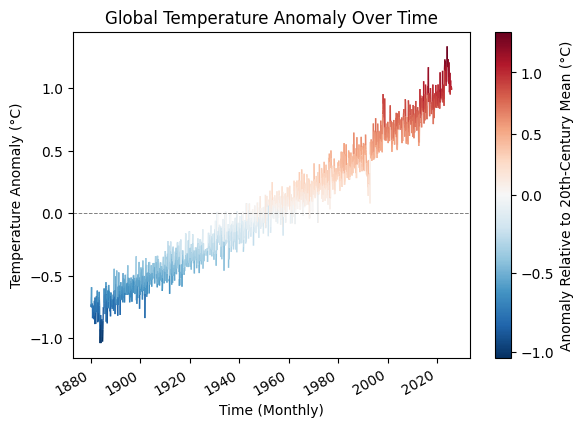

In [198]:

line_collection = mc.LineCollection(segments, cmap=cmap, norm=norm)
line_collection.set_array(d_values)
line_collection.set_linewidth(1)

fig, ax = plt.subplots()
ax.add_collection(line_collection)
ax.axhline(y=mu_20, color='gray', linestyle='--', linewidth=0.7, label='20th Century Mean (1901-2000)')

ax.set_xlabel('Time (Monthly)')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Global Temperature Anomaly Over Time')

# Set limits based on data range
ax.autoscale_view()


# Format x-axis dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(20))
fig.autofmt_xdate()

# Create and label the colorbar
cbar = fig.colorbar(line_collection, ax=ax, label='Anomaly Relative to 20th-Century Mean (°C)')
plt.show()